In [2]:
import os
from pathlib import Path
import gc

import numpy as np
import matplotlib.pyplot as plt

import keras

import torch
from torch.utils.data import DataLoader, TensorDataset 

from skyrmion_dataset import SKYRMION

os.environ["KERAS_BACKEND"] = "torch"

2025-07-08 10:12:37.567136: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-08 10:12:37.567609: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-08 10:12:37.569562: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-08 10:12:37.575363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751962357.585289  239977 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751962357.58

In [3]:
base_path = Path(os.environ["SKYRMION_BASE_PATH"])
skyrmion = SKYRMION(path=(base_path / "data" / "train" / "skyrmion_dataset_sub").with_suffix(".npz"))

def process_element(example):
        image, label = torch.from_numpy(example["image"]), torch.tensor(example["label"], dtype=torch.int64)
        return image, torch.nn.functional.one_hot(label, len(SKYRMION.LABELS))

test = skyrmion.test.transform(process_element)
dataloader = torch.utils.data.DataLoader(test, batch_size=16)

In [19]:
model_path = Path("saved_models") / "final" / "sub" / "activation2" / "model5-2025-07-08_020424-act=linear,dec=plateau,ear=True,fag=G,fil=32,lea=0.keras" # CNN gelu
# model_path = Path("saved_models") / "sub" / "best" / "ffn-2025-06-20_195509-act=gelu,dec=plateau,dep=1,dro=0.5,ear=True,fil=64,lab=0.05,lea=0.01,los=focal,pad=valid,per=True,pha=N+c+c,see=5,wei=0.keras"
models = {"test-model": keras.models.load_model(model_path, compile=False)}
model = models["test-model"]


In [24]:
images, labels, preds = [], [], []
with torch.no_grad():
    for batch in dataloader:
        batch_images = batch[0].to("cpu")
        preds.extend(model(batch_images).cpu().numpy())
        images.extend(batch[0])
        labels.extend(batch[1])

preds = np.array(preds)
images = np.array(images)
labels = np.array(labels)

errors = np.abs(preds - labels).sum(axis=1)
total_err = np.sum(errors)

In [21]:
total_err

1.2251856112418693

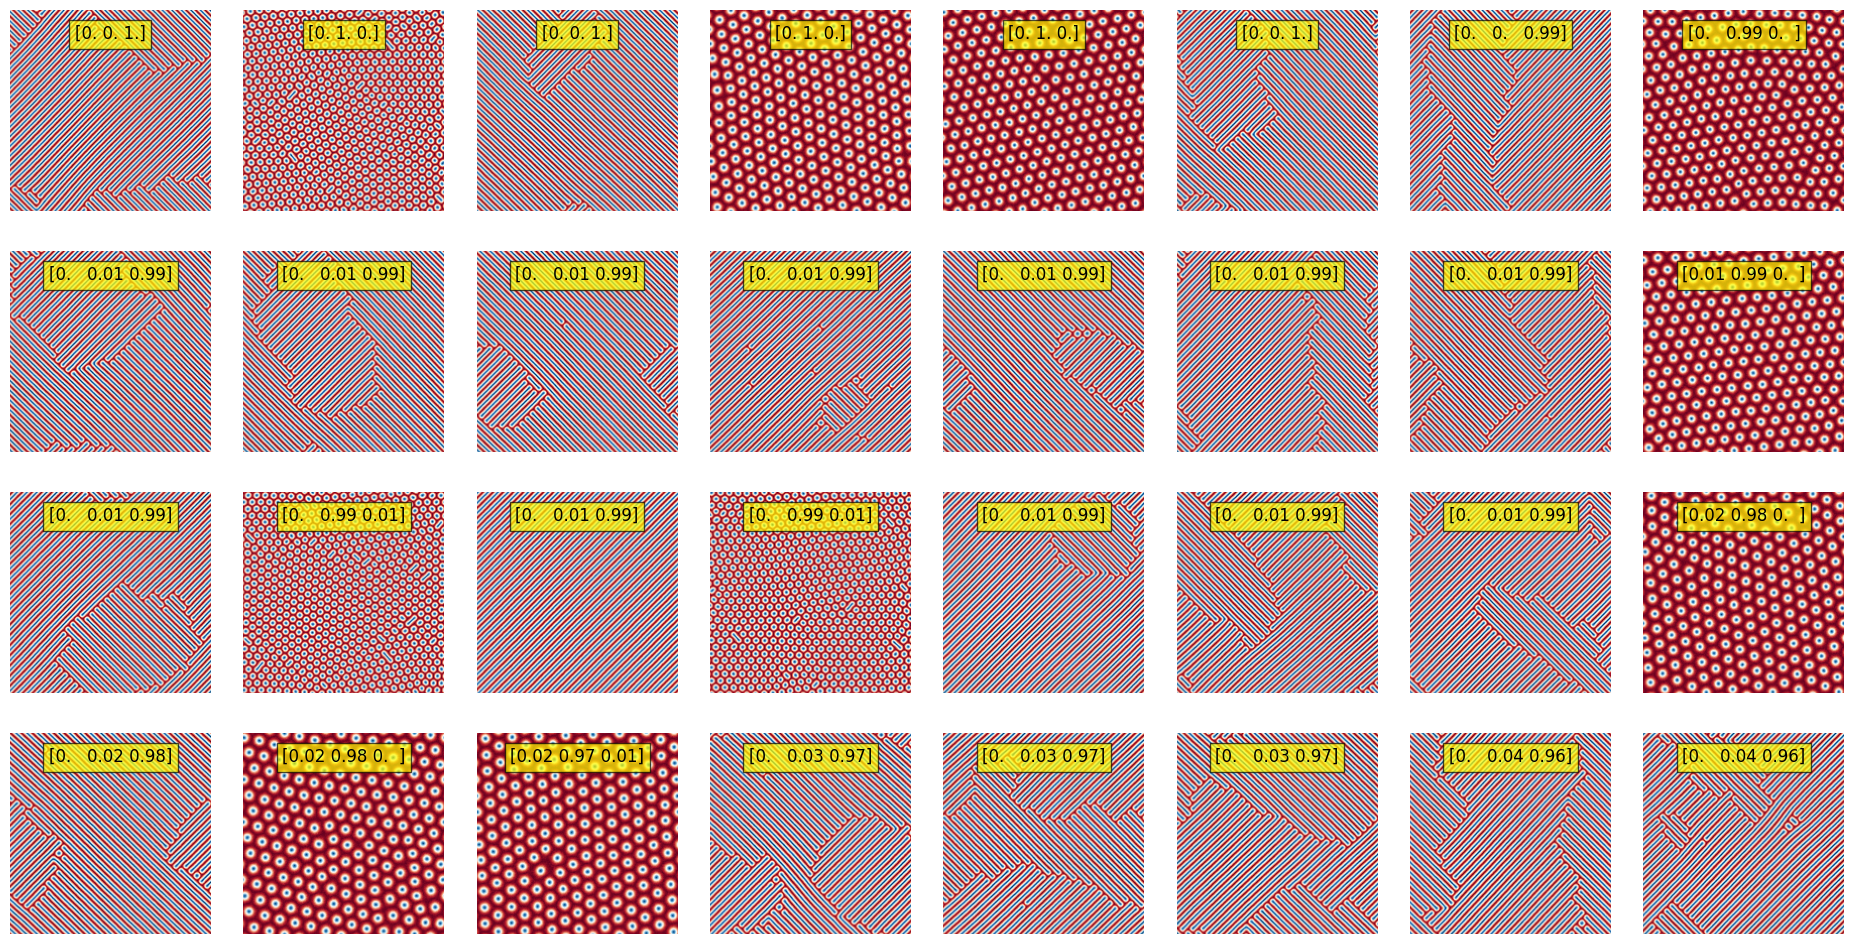

In [22]:
n_worst = 32
worst_idcs = np.argsort(errors)[-n_worst:]

worst_samples = {
    "images": images[worst_idcs],
    "labels": labels[worst_idcs],
    "preds": preds[worst_idcs]
}

fig = SKYRMION.visualize_images(worst_samples["images"].squeeze(-1), labels=worst_samples["preds"], row_size=8, base_size=3, show_images=False)